# Medical Insurance Cost Prediction

This notebook explores the medical insurance dataset, performs exploratory data analysis (EDA), and trains baseline regression models to predict `charges`.


## Data acquisition (Kaggle)

Download the dataset directly from Kaggle using `kagglehub`.


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rahulvyasm/medical-insurance-cost-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'medical-insurance-cost-prediction' dataset.
Path to dataset files: /kaggle/input/medical-insurance-cost-prediction


## Libraries

Import core libraries for data handling, visualization, and machine learning.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import scipy.stats as stats
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

sns.set_theme(style="white")
palette = ["#B0C4DE", "#006400", "#0099CC", "#CCFFFF"]

## Load the dataset

Read the CSV file downloaded from Kaggle and confirm the number of rows.


In [8]:
import os

csv_path = next(
    (os.path.join(path, f) for f in os.listdir(path) if f.lower().endswith(".csv")),
    None,
)
if csv_path is None:
    raise FileNotFoundError(f"No CSV found in {path}")

dataset = pd.read_csv(csv_path)
print("Loaded:", csv_path, "rows:", len(dataset))

Loaded: /kaggle/input/medical-insurance-cost-prediction/medical_insurance.csv rows: 2772


## Quick inspection

Review the dataset structure, datatypes, and summary statistics.


In [9]:
dataset.head

<bound method NDFrame.head of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
2767   47  female  45.320         1     no  southeast   8569.86180
2768   21  female  34.600         0     no  southwest   2020.17700
2769   19    male  26.030         1    yes  northwest  16450.89470
2770   23    male  18.715         0     no  northwest  21595.38229
2771   54    male  31.600         0     no  southwest   9850.43200

[2772 rows x 7 columns]>

In [11]:
dataset.shape

(2772, 7)

In [13]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [15]:
dataset.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,2772.0,NaN,NaN,NaN,39.109668,14.081459,18.0,26.0,39.0,51.0,64.0
sex,2772,2,male,1406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,2772.0,NaN,NaN,NaN,30.701349,6.129449,15.96,26.22,30.4475,34.77,53.13
children,2772.0,NaN,NaN,NaN,1.101732,1.214806,0.0,0.0,1.0,2.0,5.0
smoker,2772,2,no,2208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,2772,4,southeast,766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,2772.0,NaN,NaN,NaN,13261.369959,12151.768945,1121.8739,4687.797,9333.01435,16577.7795,63770.42801


### Missing values

Check for missing data in each column.


In [16]:
dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


**Observation**: If all counts are zero, the dataset has no missing values and no imputation is required for modeling.


### Column groups

Separate categorical and numeric features to support EDA and preprocessing steps.


In [21]:
object_cols = dataset.select_dtypes(include=["object"]).columns.tolist()
int_cols = dataset.select_dtypes(include=["int64"]).columns.tolist()
float_cols = dataset.select_dtypes(include=["float64"]).columns.tolist()
numeric_cols = int_cols + float_cols
target_column = "charges"

In [22]:
unique_counts = dataset[object_cols].nunique()
# Get list of unique values from each column
unique_values_list = []
for column_name, count in unique_counts.items():
    unique_values = dataset[column_name].unique().tolist()
    unique_values_list.append(unique_values)
for column_name, unique_values in zip(unique_counts.index, unique_values_list):
    print(f"Column: {column_name}")
    print(f"Values: {unique_values}")
    print()

Column: sex
Values: ['female', 'male']

Column: smoker
Values: ['yes', 'no']

Column: region
Values: ['southwest', 'southeast', 'northwest', 'northeast']



### Duplicate rows

Identify exact duplicate records before modeling.


In [24]:
# Duplicates count
dataset.duplicated().sum()

np.int64(1435)

**Observation**: If the duplicate count is non-zero, consider removing duplicates with `dataset.drop_duplicates()` before training.


In [25]:
unique_counts = dataset[object_cols].nunique()
print(unique_counts)

sex       2
smoker    2
region    4
dtype: int64


## Exploratory Data Analysis (EDA)

Visualize categorical distributions and relationships with the target (`charges`).


In [39]:
# Functions


def create_boxplot_chart(dataset, statistics_column, target_column):
    plt.figure(figsize=(10, 6))
    distribution = sns.boxplot(
        data=dataset, x=statistics_column, y=target_column, palette=palette
    )
    # if len(dataset[statistics_column].unique()) > 2:
    #    plt.xticks(rotation=90)


def create_pie_chart(dataset, statistics_column, target_column):
    value_count = dataset[statistics_column].value_counts()
    plt.figure(figsize=(10, 6))
    plt.pie(value_count, labels=value_count.index, colors=palette)
    plt.title(statistics_column)


def create_scatter_chart(dataset, statistics_column, target_column):
    plt.figure(figsize=(10, 6))
    plt.scatter(dataset[statistics_column], dataset[target_column])
    plt.xlabel(statistics_column)
    plt.ylabel(target_column)
    plt.show()


def create_kde_chart(dataset, statistics_column, target_column):
    plt.figure(figsize=(10, 6))
    if target_column == "":
        sns.kdeplot(
            x=dataset[statistics_column], fill=True, multiple="layer", legend=True
        )
        plt.ylabel("Density")
    else:
        sns.kdeplot(
            x=dataset[statistics_column],
            y=dataset[target_column],
            fill=True,
            multiple="layer",
            legend=True,
        )
        plt.ylabel(target_column)
    plt.title("Smooth Histogram (KDE)")
    plt.xlabel(statistics_column)

### Categorical distributions

Pie charts show the proportion of each category (e.g., smoker vs non-smoker).


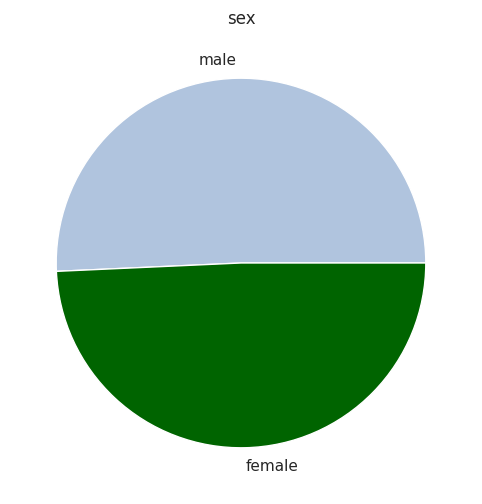

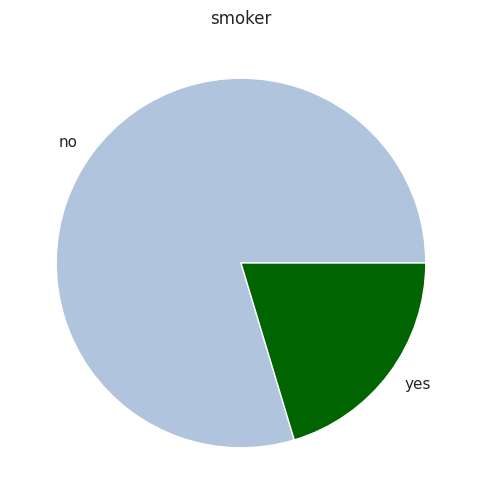

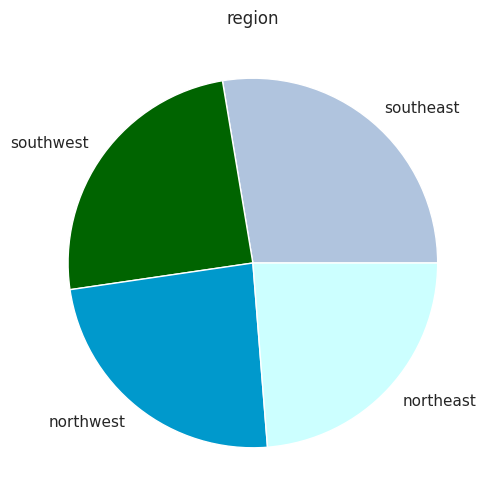

In [40]:
for col in object_cols:
    create_pie_chart(dataset, col, target_column)

### Charges by category

Boxplots show how `charges` vary across categories.


/tmp/ipython-input-339098352.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  distribution=sns.boxplot(data=dataset,x=statistics_column, y=target_column, palette=palette)
/tmp/ipython-input-339098352.py:5: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  distribution=sns.boxplot(data=dataset,x=statistics_column, y=target_column, palette=palette)
/tmp/ipython-input-339098352.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  distribution=sns.boxplot(data=dataset,x=statistics_column, y=target_column, palette=palette)
/tmp/ipython-input-339098352.py:5: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  distribution=sns.bo

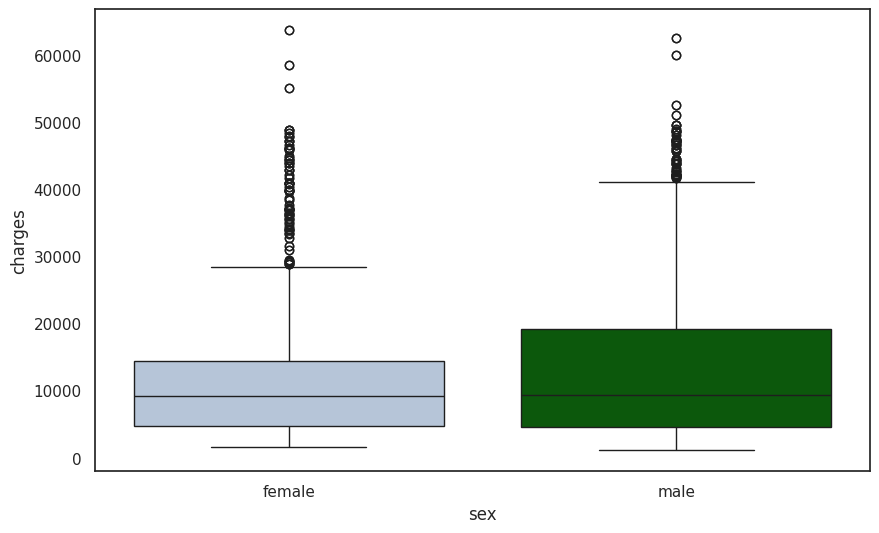

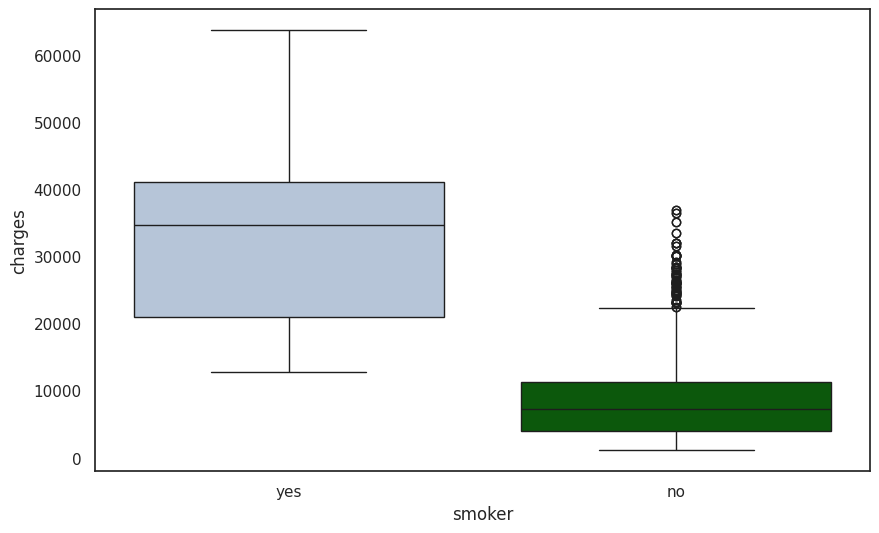

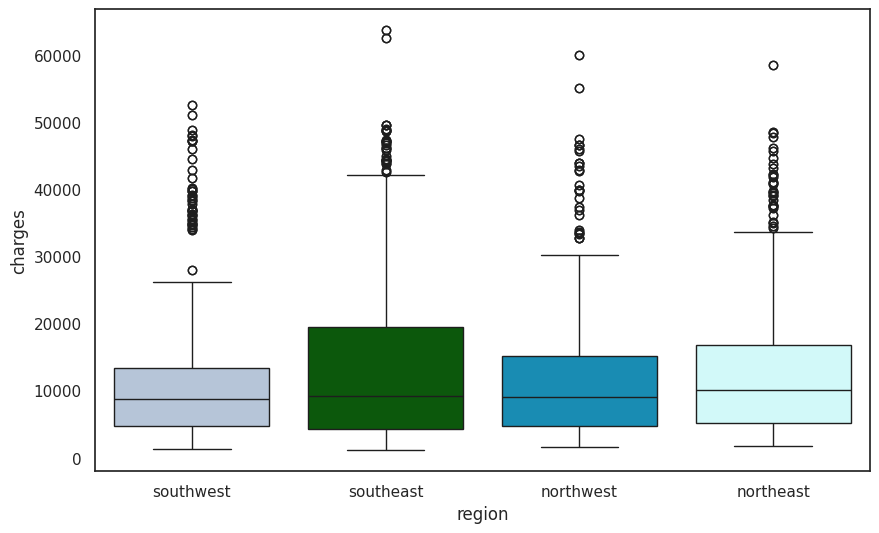

In [41]:
for col in object_cols:
    create_boxplot_chart(dataset, col, target_column)

### Numeric relationships

Scatter plots visualize the relationship between numeric features and `charges`.


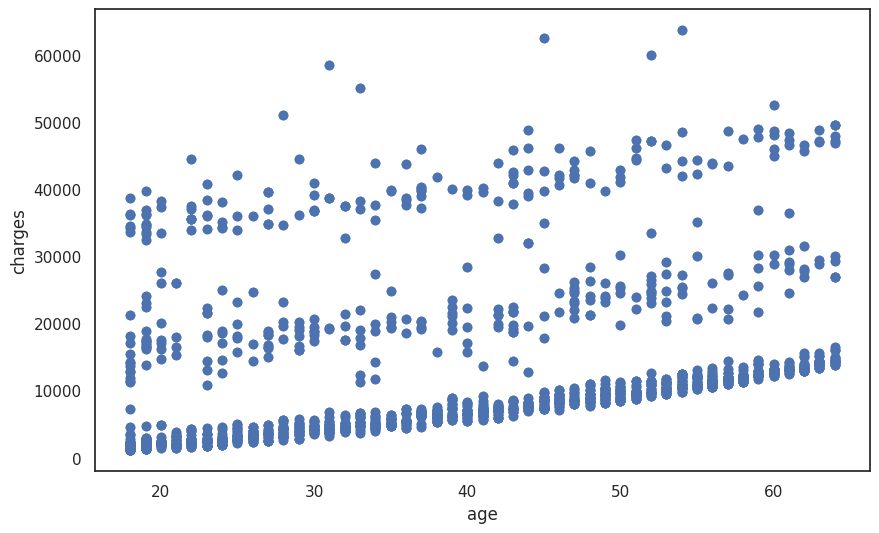

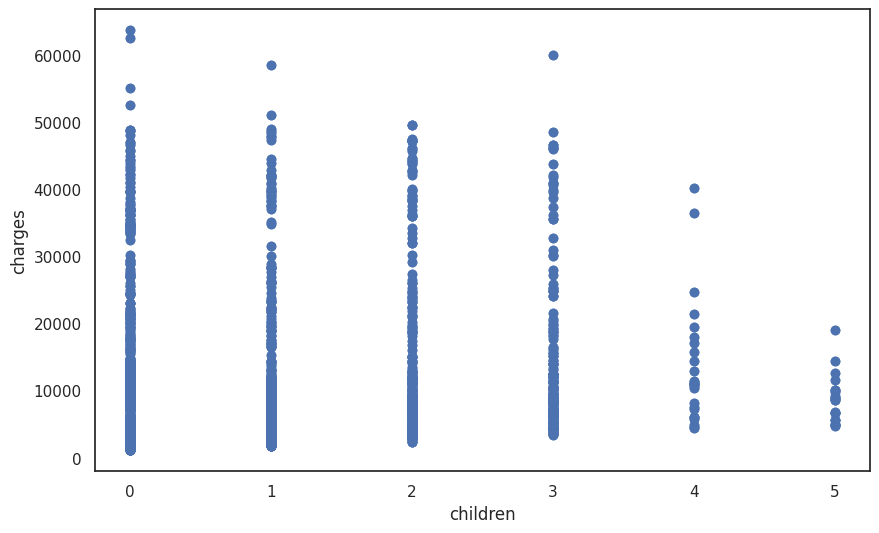

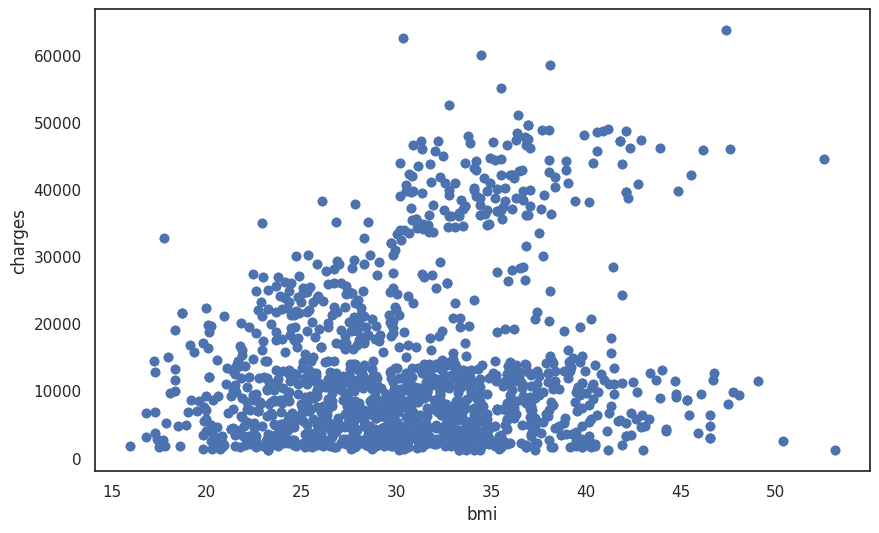

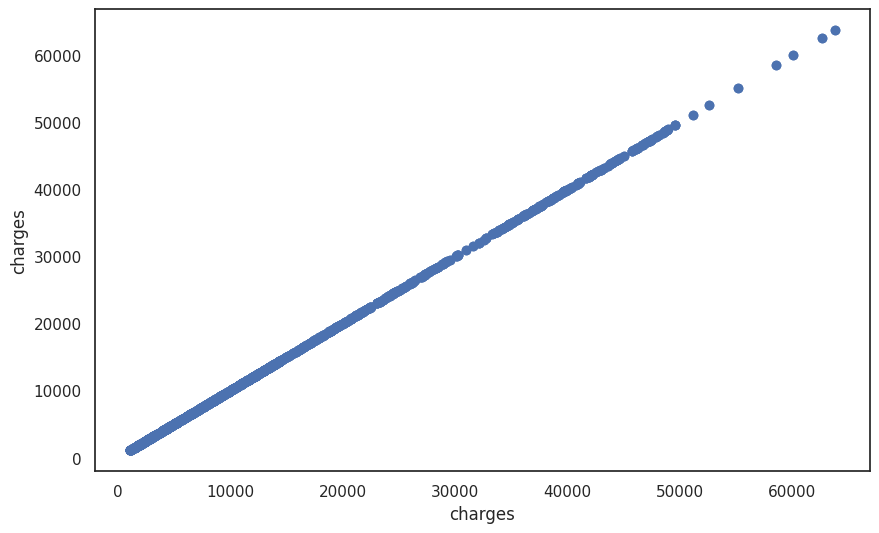

In [43]:
for col in numeric_cols:
    create_scatter_chart(dataset, col, target_column)

### Density plots

KDE plots show feature distributions and how density changes with `charges`.


/tmp/ipython-input-339098352.py:28: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=dataset[statistics_column], y=dataset[target_column], fill=True, multiple='layer',legend=True)


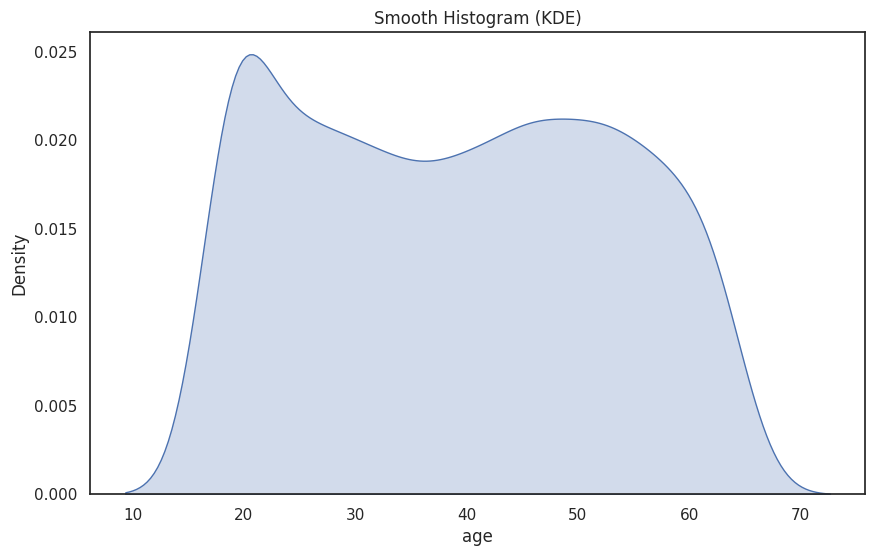

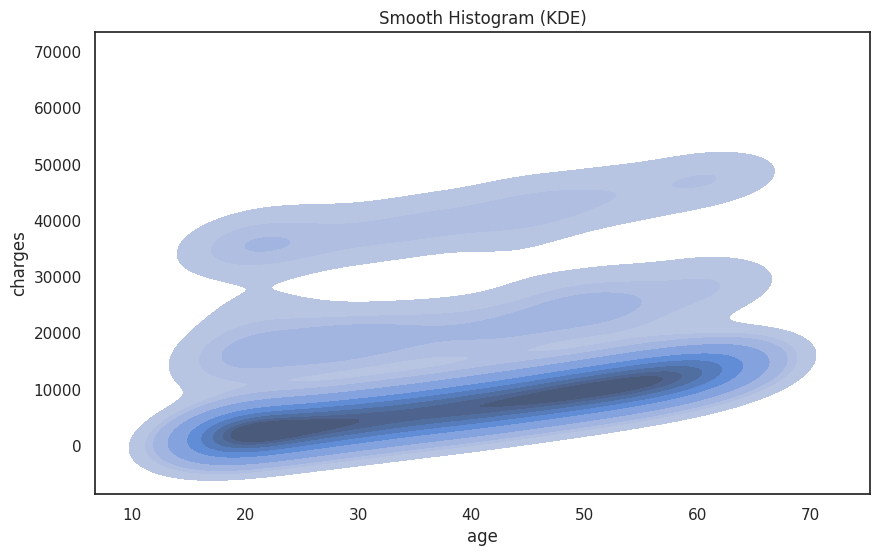

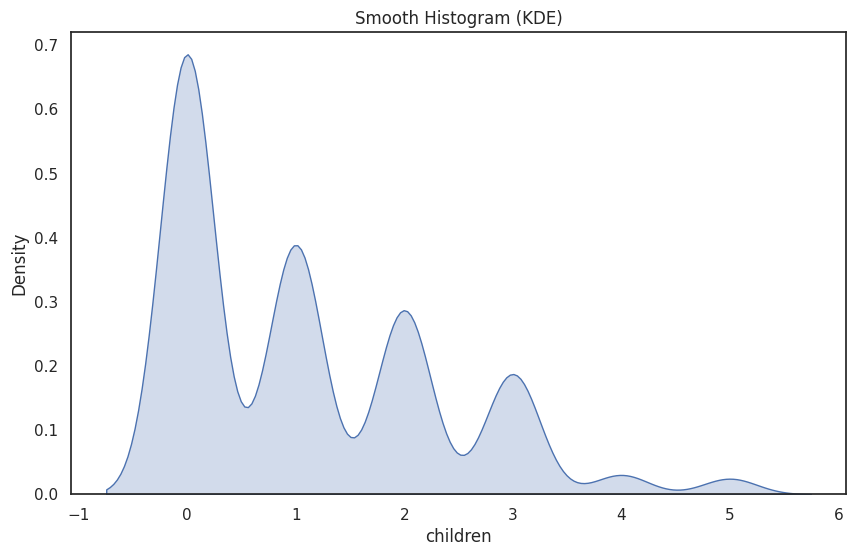

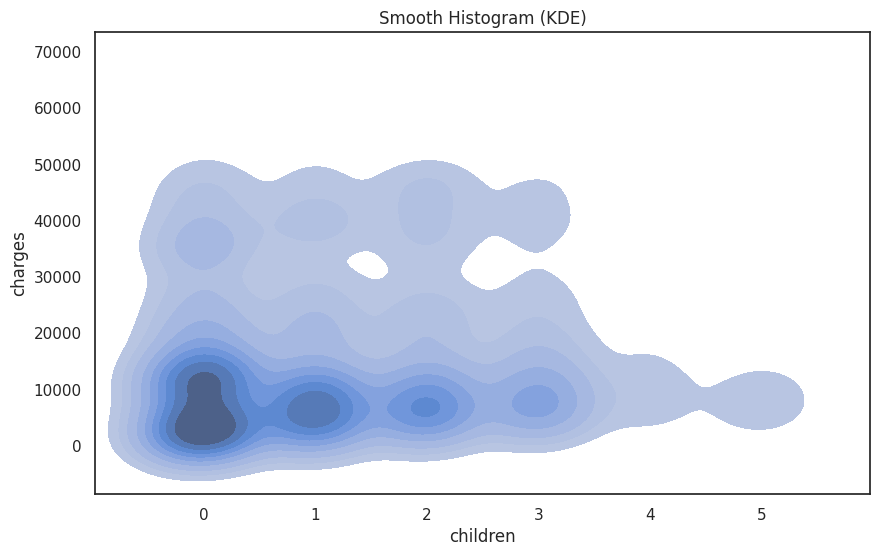

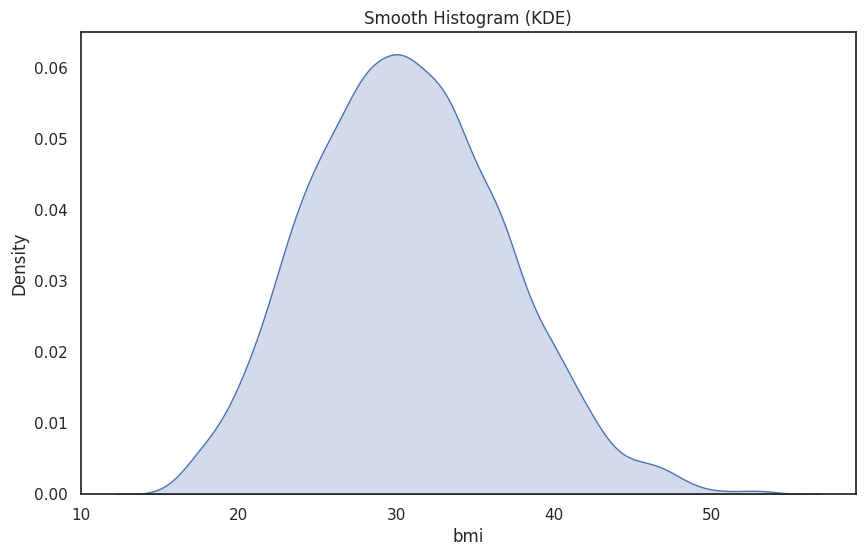

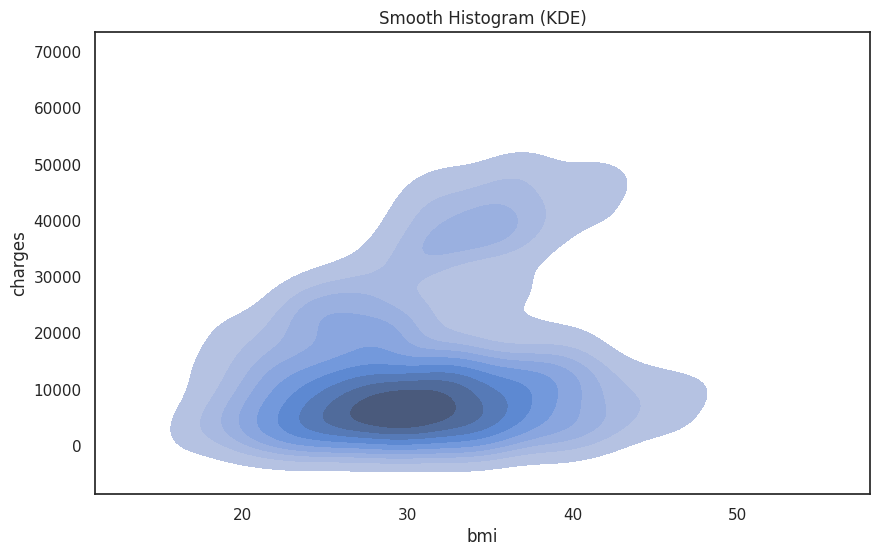

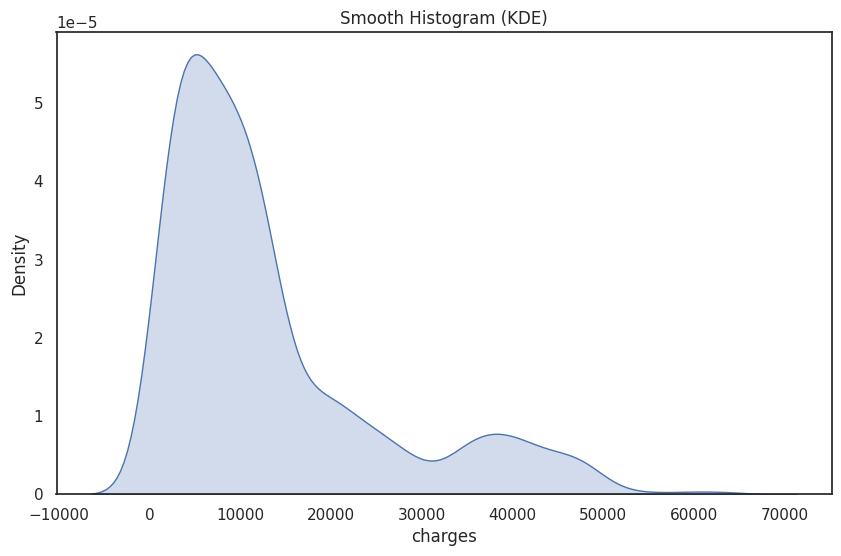

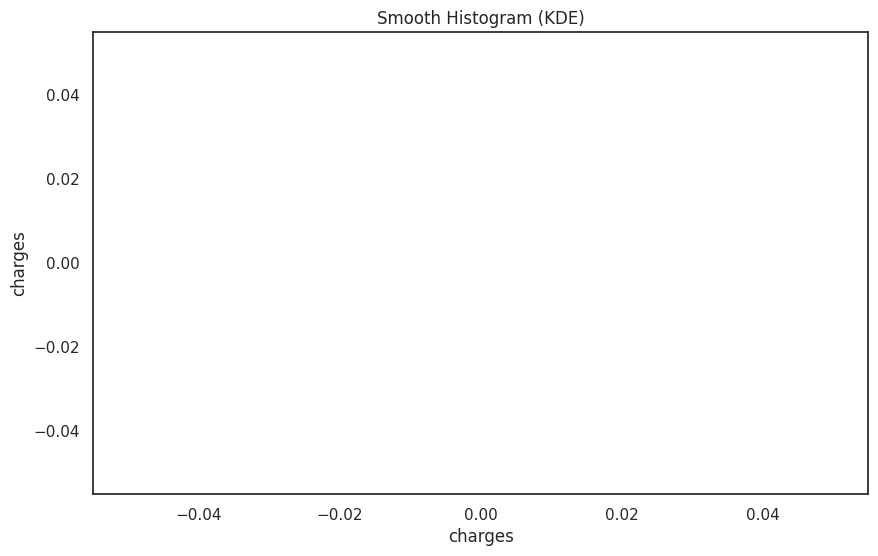

In [45]:
for col in numeric_cols:
    create_kde_chart(dataset, col, "")
    create_kde_chart(dataset, col, target_column)

## Normality checks

Q-Q plots help assess whether numeric features are approximately normally distributed.


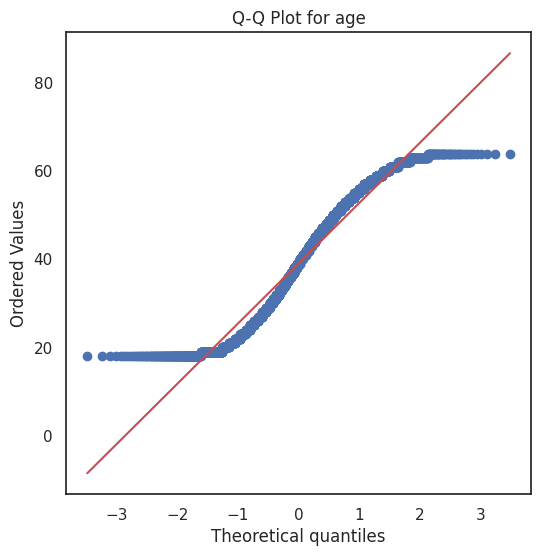

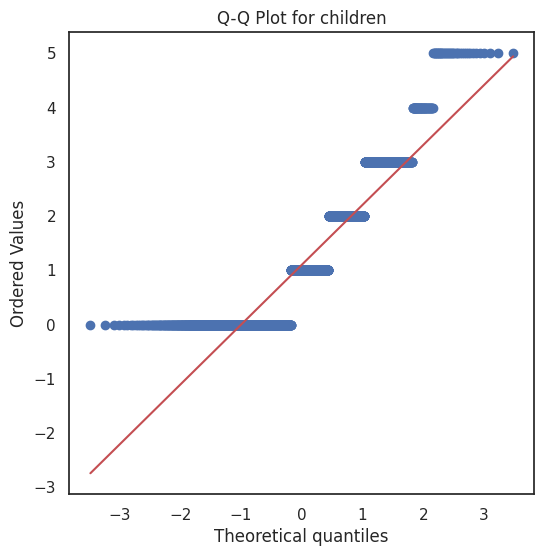

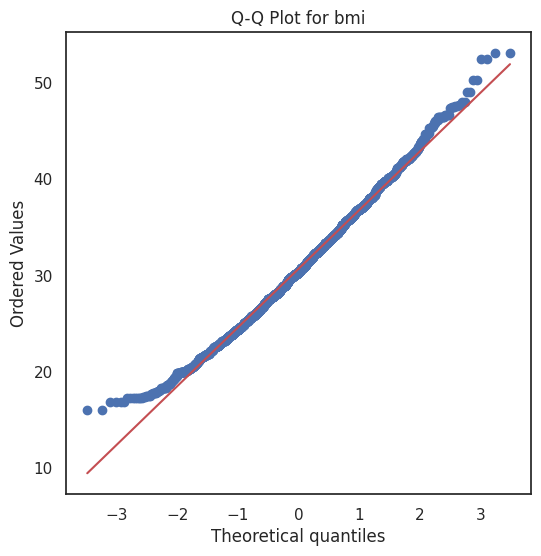

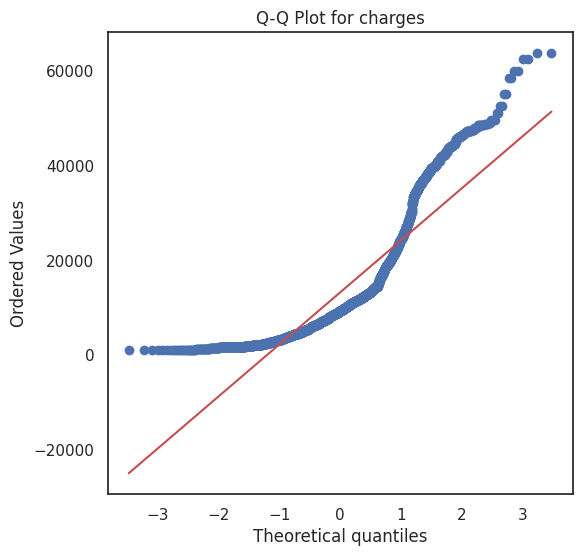

In [46]:
for col in numeric_cols:
    plt.figure(figsize=(6, 6))
    stats.probplot(dataset[col], dist="norm", plot=plt)
    plt.title("Q-Q Plot for " + col)
    plt.show()

## Correlation analysis

Encode categorical variables and compute a correlation matrix to inspect linear relationships.


In [47]:
df_corelation_analysis = dataset

In [48]:
df_encoded = pd.get_dummies(df_corelation_analysis)

<Axes: >

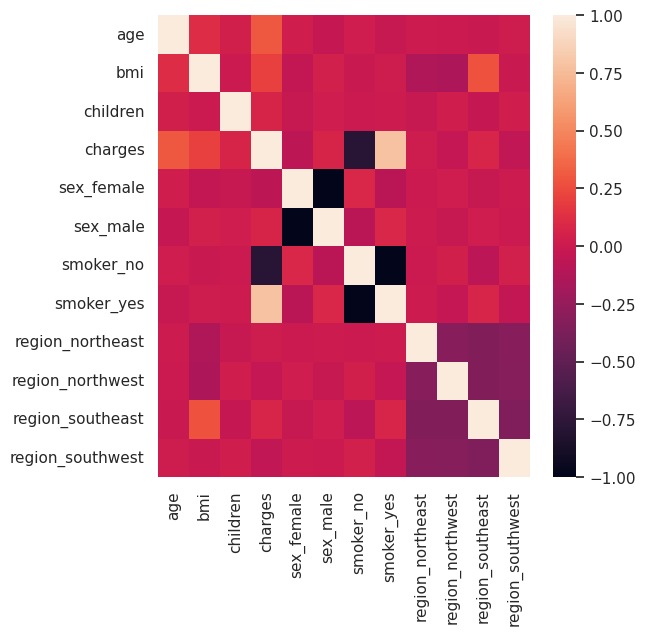

In [49]:
corr = df_encoded.corr()
plt.figure(figsize=(6, 6))
sns.heatmap(corr)

## Modeling and evaluation

Train several baseline regression models and compare performance on train vs test splits.


In [50]:
def create_model_and_predictions(model_tuple, X_train, y_train, X_test, y_test):
    model_name, model = model_tuple
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    evaluate_model("Train", y_train, y_train_pred)
    evaluate_model("Test", y_test, y_test_pred)


def evaluate_model(train_or_test, y_actual, y_predicted):
    print()

    mae = mean_absolute_error(y_actual, y_predicted)
    mse = mean_squared_error(y_actual, y_predicted)
    r2 = r2_score(y_actual, y_predicted)

    print(f"{train_or_test} Mean Absolute Error (MAE): {mae:.4f}")
    print(f"{train_or_test} Mean Squared Error (MSE): {mse:.4f}")
    print(f"{train_or_test} R-squared (R²) Score: {r2:.4f}")

    print("-" * 50)


models = [
    ("Random Forest", RandomForestRegressor()),
    ("Linear Regression", LinearRegression()),
    ("Support Vector Machine", SVR()),
    ("Naive Bayes", BayesianRidge()),
    ("AdaBoost", AdaBoostRegressor()),
]

### Preprocessing pipeline

One-hot encode categorical features and scale selected numeric features.


In [52]:
multicolumn_prep = ColumnTransformer(
    [
        # ('drop', 'drop', ['State', 'PatientID']),
        # ('handle_missing', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        (
            "encode_multicategorical",
            OneHotEncoder(sparse_output=False),
            ["sex", "region", "smoker"],
        ),
        ("feature_scaling", MinMaxScaler(), ["children", "bmi"]),
    ],
    remainder="passthrough",
)

### Train/test split

Split the data into training and testing sets for evaluation.


In [54]:
X = dataset.drop(target_column, axis=1)
y = dataset[target_column]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.7, random_state=21
)

In [55]:
X_train_preprocessed = multicolumn_prep.fit_transform(X_train)
X_test_preprocessed = multicolumn_prep.transform(X_test)

In [56]:
for model in models:
    create_model_and_predictions(
        model, X_train_preprocessed, y_train, X_test_preprocessed, y_test
    )

Training Random Forest...

Train Mean Absolute Error (MAE): 758.7999
Train Mean Squared Error (MSE): 2311264.9457
Train R-squared (R²) Score: 0.9850
--------------------------------------------------

Test Mean Absolute Error (MAE): 2209.2809
Test Mean Squared Error (MSE): 19066492.3985
Test R-squared (R²) Score: 0.8683
--------------------------------------------------
Training Linear Regression...

Train Mean Absolute Error (MAE): 4352.5935
Train Mean Squared Error (MSE): 39578355.1575
Train R-squared (R²) Score: 0.7435
--------------------------------------------------

Test Mean Absolute Error (MAE): 4120.2618
Test Mean Squared Error (MSE): 35802170.9454
Test R-squared (R²) Score: 0.7527
--------------------------------------------------
Training Support Vector Machine...

Train Mean Absolute Error (MAE): 8491.8529
Train Mean Squared Error (MSE): 172567980.0393
Train R-squared (R²) Score: -0.1183
--------------------------------------------------

Test Mean Absolute Error (MAE): 82

## Cross-validation

Estimate model stability and generalization by averaging performance across folds.


In [57]:
model = RandomForestRegressor()
cross_validation = cross_val_score(
    model, X_train_preprocessed, y_train, scoring="r2", cv=10
)
print("Cross-validation scores for each fold:", cross_validation)

print("Average cross-validation score:", cross_validation.mean())

Cross-validation scores for each fold: [0.89240911 0.87586934 0.91633926 0.85951379 0.91764785 0.89842386
 0.87848955 0.82680597 0.91824951 0.83385348]
Average cross-validation score: 0.88176017382241


## Hyperparameter tuning

Search for the best Random Forest hyperparameters using grid search with cross-validation.


In [60]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
}

In [61]:
model = RandomForestRegressor()

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring="r2", cv=10)
grid_search.fit(X_train_preprocessed, y_train)

print("Best Hyperparameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)

Best Hyperparameters:  {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Score:  0.884307704036209
